<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [37]:
# imports
from IPython.display import Image, display
from IPython.display import HTML, Markdown
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

# **Feature Engineering – Group 2: Feature Transformation**

**Authors:** *Nora Beringer, Malte Gerboth, Haben Ghebremeskel Tekle, Janic Rüegg, Daniel Chung, Raphael Lüthy*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/02_Feature_Transformation.png" width="1200"/>

## Introduction

**What is it about?**
*Feature transformation* changes the representation of a feature so that a model can use it more easily. Monotonic transforms such as the logarithm or the square root compress long-tailed distributions and turn multiplicative effects into additive ones. Categorical variables must be turned into numbers, via one-hot encoding for nominal and label (ordinal) encoding for ordered categories. Polynomial features let linear models capture non-linear relationships, and periodic features such as time of day, weekday or angle are best encoded with sine/cosine pairs or radial basis functions so that "23:59" and "00:01" end up close together.

**Where is it used?**
Everywhere tabular data is modelled: prices and incomes (log transform), customer or product categories (one-hot encoding), physical models with interactions (polynomial features), and time series with daily, weekly or seasonal cycles such as energy demand, traffic or sales forecasting (cyclic encoding).

**Why is it important for Machine Learning?**
Most learners make implicit assumptions about their inputs: linear models assume linear effects, distance-based models assume meaningful distances, and no model can directly digest strings. A well-chosen transformation can turn a hard problem into an easy one, often with a simpler model. A poorly chosen one (e.g. label-encoding nominal categories or blindly one-hot encoding high-cardinality features) introduces false orderings, sparsity and the curse of dimensionality.

## (i) Why and when feature transformations make sense



**Why?**  
Feature transformations make sense when the original features do not fit the assumptions or requirements of the machine learning model.

**What do they do?**  
They reshape features to make their **distribution, scale, or relationships** more suitable for modeling.

**When?**
- **Different scales** → standardization / normalization
- **Skewed data** → log or other mathematical transformations
- **Outliers** → transformations can reduce their influence
- **Categorical data** → encode categories numerically
- **Nonlinear relationships** → transform features to make patterns easier to model

**Key idea:**  
> **Transform the features when their current representation makes it harder for the model to learn effectively.**


## (ii) Log, square root, and monotonic transforms



## (iii) Categorical features: nominal → one-hot encoding, ordinal → ordinal encoding
Models compute with numbers, so text categories like "red" or "medium" must be encoded first. How we encode them depends on whether the categories have an order:

- **Nominal** features have no natural order (colour, country, payment method) → **one-hot encoding**
- **Ordinal** features have a clear order (clothing size: S < M < L) → **ordinal encoding**

### One-hot encoding
Create one 0/1 column per category. "red", "green" and "blue" become three indicator columns, and each row has exactly one 1, so no colour is ranked above another. The cost is one extra column per category: a high-cardinality feature such as postcodes quickly makes the data wide and sparse (see section (iv)).

### Ordinal encoding
Map the categories to integers in their real order, keeping a single column: S → 0, M → 1, L → 2. Two caveats:
- The model treats the codes as equally spaced: *S → M* counts as the same step as *M → L*, even if the real gap is different.
- In scikit-learn, use `OrdinalEncoder` with explicit `categories=`. `LabelEncoder` is meant for target labels, not input features.

**Rule of thumb:** if you can't say which category is "more", the feature is nominal, so use one-hot encoding.

### Example
Let's look at a small dataset of 24 Swiss hiking trips: where people went, how they got there, which snack they packed, and how hard, hungry and happy the trip was.

In [38]:
import pandas as pd

swiss_trips = pd.read_csv("data/swiss_hiking_snacks.csv")

nominal_features = ["canton", "transport", "snack"]
ordinal_orders = {
    "trail_difficulty": ["Easy", "Moderate", "Challenging"],
    "hunger": ["Not hungry", "Peckish", "Hungry", "Very hungry"],
    "satisfaction": ["Unhappy", "Neutral", "Happy", "Delighted"],
}

swiss_trips.head(3)

,trip_id,canton,transport,snack,trail_difficulty,hunger,satisfaction
0,CH001,Valais,Train,Raclette,Moderate,Very hungry,Delighted
1,CH002,Bern,PostBus,Chocolate,Easy,Peckish,Happy
2,CH003,Graubuenden,Cable car,Nusstorte,Challenging,Hungry,Neutral


Each trip has three **nominal** features (`canton`, `transport`, `snack`): there is no natural order between Valais and Ticino, or between a train and a cable car. It also has three **ordinal** features (`trail_difficulty`, `hunger`, `satisfaction`), whose categories have a clear order. So we encode the two groups differently.

#### Step 1: One-hot encode the nominal features
We start with `snack`. `OneHotEncoder` creates one 0/1 column for each snack. In every row, exactly one of these columns is `1`: the one for that trip's snack. With `handle_unknown="ignore"`, a snack the encoder has never seen (e.g. in new data at prediction time) does not raise an error; it simply gets `0` in all snack columns.

In [39]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

onehot = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
snack_onehot = pd.DataFrame(
    onehot.fit_transform(swiss_trips[["snack"]]).astype(int),
    columns=onehot.get_feature_names_out(),
    index=swiss_trips.index,
)

pd.concat([swiss_trips[["snack"]], snack_onehot], axis=1).head(6)

,snack,snack_Appenzeller cheese,snack_Chocolate,snack_Nusstorte,snack_Polenta,snack_Raclette
0,Raclette,0,0,0,0,1
1,Chocolate,0,1,0,0,0
2,Nusstorte,0,0,1,0,0
3,Appenzeller cheese,1,0,0,0,0
4,Polenta,0,0,0,1,0
5,Raclette,0,0,0,0,1


#### Step 2: Ordinal encode the ordinal features
For ordinal features we pass the order **explicitly** via `categories=`. Each feature stays a single column, and a larger number means "more difficult", "hungrier" or "happier".

In [40]:
ordinal_features = list(ordinal_orders)

display(Markdown(
    "**Ordinal features and their order:**\n\n"
    + "\n".join(f"- `{feature}`: " + " < ".join(order) for feature, order in ordinal_orders.items())
))

ordinal = OrdinalEncoder(categories=list(ordinal_orders.values()))
ordinal_encoded = pd.DataFrame(
    ordinal.fit_transform(swiss_trips[ordinal_features]).astype(int),
    columns=[f"{feature}_encoded" for feature in ordinal_features],
    index=swiss_trips.index,
)

pd.concat([swiss_trips[ordinal_features], ordinal_encoded], axis=1).head(6)

**Ordinal features and their order:**

- `trail_difficulty`: Easy < Moderate < Challenging
- `hunger`: Not hungry < Peckish < Hungry < Very hungry
- `satisfaction`: Unhappy < Neutral < Happy < Delighted

,trail_difficulty,hunger,satisfaction,trail_difficulty_encoded,hunger_encoded,satisfaction_encoded
0,Moderate,Very hungry,Delighted,1,3,3
1,Easy,Peckish,Happy,0,1,2
2,Challenging,Hungry,Neutral,2,2,1
3,Easy,Not hungry,Happy,0,0,2
4,Moderate,Hungry,Delighted,1,2,3
5,Challenging,Very hungry,Unhappy,2,3,0


#### What goes wrong if we mix them up?
Without explicit categories, `OrdinalEncoder` simply sorts the categories **alphabetically**. This causes two problems:

- **Nominal feature as integers:** the snacks get the numbers 0–4. A linear model now believes that Raclette (4) is "four times more snack" than Chocolate (1), and that the average of Appenzeller cheese (0) and Raclette (4) is a Nusstorte (2). 🧀 + 🫕 = 🥧?
- **Ordinal feature without explicit order:** alphabetically, *Challenging* < *Easy* < *Moderate*, so the trail order is scrambled.

In [41]:
lines = []
for feature in ["snack", "trail_difficulty"]:
    naive = OrdinalEncoder().fit(swiss_trips[[feature]])
    mapping = ", ".join(f"{category} → {code}" for code, category in enumerate(naive.categories_[0])) # type: ignore
    lines.append(f"- `{feature}`: {mapping}")
display(Markdown("**Naive integer encoding (alphabetical):**\n\n" + "\n".join(lines)))

**Naive integer encoding (alphabetical):**

- `snack`: Appenzeller cheese → 0, Chocolate → 1, Nusstorte → 2, Polenta → 3, Raclette → 4
- `trail_difficulty`: Challenging → 0, Easy → 1, Moderate → 2

#### Seeing it: which distances does the model "see"?
Many models (k-NN, SVMs, clustering, linear models with regularisation) work with **distances** between samples. The encoding decides these distances. Each panel below picks one category and shows how far every other category is from it after encoding:

- **Top left:** with integer encoding, the snacks form a staircase. Appenzeller cheese is 4 away from Raclette, but Polenta is only 1 away. That ranking comes from the alphabet, not from the snacks.
- **Top right:** with one-hot encoding, all bars are equal: every other snack is $\sqrt{2} \approx 1.41$ away. No snack is "closer" than another, which is exactly what *nominal* means.
- **Bottom left:** for `trail_difficulty` the integer distances *are* meaningful. Easy → Moderate is one step, Easy → Challenging is two.
- **Bottom right:** one-hot encoding flattens this order and uses more columns.

**Rule of thumb:** pick the encoding whose distances match how you think about the categories: a staircase for ordered categories, flat bars for unordered ones.

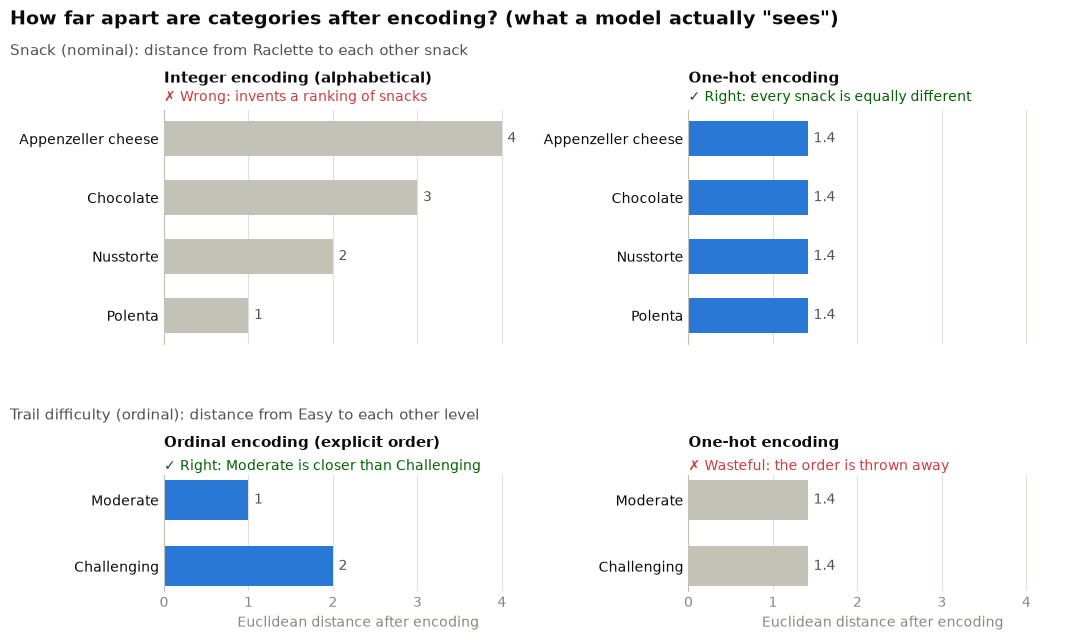

In [42]:
from sklearn.metrics import pairwise_distances


def distances_from(reference, categories, encoder):
    """Euclidean distance from `reference` to every other category after encoding."""
    encoded = encoder.fit_transform(pd.DataFrame({"x": categories}))
    dist = pd.Series(pairwise_distances(encoded)[categories.index(reference)], index=categories)
    return dist.drop(reference)


snacks = sorted(swiss_trips["snack"].unique())
difficulties = ordinal_orders["trail_difficulty"]

rows = [
    ("Snack (nominal): distance from Raclette to each other snack", [
        ("Integer encoding (alphabetical)", False, "Wrong: invents a ranking of snacks",
         distances_from("Raclette", snacks, OrdinalEncoder())),
        ("One-hot encoding", True, "Right: every snack is equally different",
         distances_from("Raclette", snacks, OneHotEncoder(sparse_output=False))),
    ]),
    ("Trail difficulty (ordinal): distance from Easy to each other level", [
        ("Ordinal encoding (explicit order)", True, "Right: Moderate is closer than Challenging",
         distances_from("Easy", difficulties, OrdinalEncoder(categories=[difficulties]))),
        ("One-hot encoding", False, "Wasteful: the order is thrown away",
         distances_from("Easy", difficulties, OneHotEncoder(sparse_output=False, categories=[difficulties]))),
    ]),
]

# colors: blue bars = good encoding, gray bars = bad encoding; verdict text in status color + icon
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BAR_GOOD, BAR_BAD = "#2a78d6", "#c3c2b7"
TEXT_GOOD, TEXT_BAD = "#006300", "#d03b3b"

xmax = max(dist.max() for _, panels in rows for *_, dist in panels) * 1.15
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [4, 2]})
fig.subplots_adjust(left=0.15, right=0.98, top=0.83, bottom=0.09, wspace=0.35, hspace=0.75)
fig.suptitle('How far apart are categories after encoding? (what a model actually "sees")',
             fontsize=14, fontweight="bold", x=0.01, y=0.985, ha="left", color=INK)

for row_axes, (row_title, panels) in zip(axes, rows):
    fig.text(0.01, row_axes[0].get_position().y1 + 0.085, row_title, fontsize=11, color=INK_2)
    for ax, (encoding, is_good, verdict, dist) in zip(row_axes, panels):
        ax.barh(dist.index, dist.values, height=0.6, color=BAR_GOOD if is_good else BAR_BAD)
        ax.bar_label(ax.containers[0], fmt="%.2g", padding=4, color=INK_2)
        ax.invert_yaxis()
        ax.set_xlim(0, xmax)
        ax.set_title(encoding, fontsize=11, fontweight="bold", loc="left", color=INK, pad=20)
        ax.text(0, 1.04, f"{'✓' if is_good else '✗'} {verdict}", transform=ax.transAxes,
                fontsize=10, color=TEXT_GOOD if is_good else TEXT_BAD)
        ax.tick_params(axis="both", length=0, labelsize=10)
        ax.tick_params(axis="x", labelcolor=MUTED)
        ax.tick_params(axis="y", labelcolor=INK)
        ax.spines[["top", "right", "bottom"]].set_visible(False)
        ax.spines["left"].set_color("#c3c2b7")
        ax.grid(axis="x", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
for ax in axes[1]:
    ax.set_xlabel("Euclidean distance after encoding", color=MUTED, fontsize=10)

plt.show()

One-hot encoding all three nominal features (6 cantons, 4 transport modes, 5 snacks) turns `3` columns into `15`, and in every row `12` of these `15` entries are 0. With only a handful of categories this is harmless. But what happens with hundreds of categories? That is the topic of the next section.

## (iv) Problems with one-hot encoding (sparsity, curse of dimensionality)



## (v) Polynomial features



## (vi) Periodic features: sine/cosine encoding and radial basis functions



## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. https://www.geeksforgeeks.org/machine-learning/feature-transformation-techniques-in-machine-learning/
2. Finney DJ. Was This in Your Statistics Textbook? V. Transformation of Data. Experimental Agriculture. 1989;25(2):165-175. doi:10.1017/S0014479700016665
3. https://www.analyticsvidhya.com/blog/2021/05/feature-transformations-in-data-science-a-detailed-walkthrough/